In [1]:
from sklift.datasets import fetch_lenta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from catboost import CatBoostClassifier, Pool
import shap

from causalml.metrics import plot_gain, auuc_score
import optuna

from sklearn.metrics import auc
from IPython.display import clear_output

from copy import deepcopy
from sklearn.utils.validation import check_consistent_length
from tqdm import tqdm
from utils import relative_uplift_auc_score, principled_uplift_curve, max_principled_uplift_curve, principled_uplift_auc_score, plot_principled_uplift_curve, sep_qini_auc_score

import warnings
warnings.filterwarnings('ignore')

import matplotlib.patches as mpatches
from sklearn.utils.validation import check_consistent_length
from sklearn.utils.extmath import stable_cumsum
from sklearn.metrics import auc
from scipy import stats
from itertools import combinations

from sklift.metrics import uplift_by_percentile

/Users/kolpakovaksenia/diploma/.dvenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
print(sys.executable)

/Users/kolpakovaksenia/diploma/.dvenv/bin/python


In [3]:
SEED = 42

In [4]:
BASE_MODEL = CatBoostClassifier(
    loss_function='Logloss',
    verbose=False,
    random_state=SEED
  )

In [5]:
dataset = fetch_lenta()
data, target, treatment = dataset.data, dataset.target, dataset.treatment

In [6]:
# Преобразование признака gender
data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})
data['gender'] = data['gender'].fillna(-1)

In [7]:
# Заполнение пропусков
data = data.fillna(-100)

In [8]:
# Удаление явных дубликатов
data = data.drop_duplicates()

In [9]:
# Разбиение на train, valid, test выборки

data['treatment'] = treatment
data['treatment'] = (data['treatment'] == 'test').astype(int)
data['target'] = target

train_val_idx, test_idx = train_test_split(data.index, test_size=0.2, random_state=SEED, stratify=data[['treatment', 'target']])

train_idx, val_idx = train_test_split(train_val_idx, test_size=0.25, random_state=SEED, stratify=data.loc[train_val_idx, ['treatment', 'target']])

X_train = data.drop(columns=['treatment', 'target']).loc[train_idx]
X_val = data.drop(columns=['treatment', 'target']).loc[val_idx]
X_test = data.drop(columns=['treatment', 'target']).loc[test_idx]

treatment_train = data['treatment'][train_idx]
treatment_val = data['treatment'][val_idx]
treatment_test = data['treatment'][test_idx]

y_train = target[train_idx]
y_val = target[val_idx]
y_test = target[test_idx]

In [10]:
X_val.shape

(137397, 193)

In [11]:
def get_uplift(model_t, model_c, X, treatment, y, selected_features):
    X_selected = X[selected_features]
    
    pred_c = model_c.predict_proba(X_selected)[:, 1]
    pred_t = model_t.predict_proba(X_selected)[:, 1]
    
    uplift_pred = pred_t - pred_c
    
    pred_data = pd.DataFrame({'uplift': uplift_pred,
                            'y': y,
                            'treatment': treatment})
    auuc = auuc_score(pred_data, outcome_col='y', treatment_col='treatment')
    puc = principled_uplift_auc_score(y, uplift_pred, treatment)
  
    print('AUUC:', auuc.squeeze())
    print('PUC:', puc)
    
    return uplift_pred, auuc, puc

In [12]:
def train_tlearner(base_model, X_train, treatment_train, y_train,
                   X_val, treatment_val, y_val,
                   selected_features, n_trials=50, metrics='puc'):

    X_train = pd.concat([X_train, treatment_train], axis=1)
    y_train = pd.concat([y_train, treatment_train], axis=1)

    base_params = {
        'loss_function': 'Logloss',
        'verbose': False,
        'random_state': SEED
    }

    def objective(trial):

        params_c = {
            'depth': trial.suggest_int('depth_c', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_c', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_c', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_c', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_c', 0, 10),
            'random_strength': trial.suggest_float('random_strength_c', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_c', 1, 100),
        }

        params_t = {
            'depth': trial.suggest_int('depth_t', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_t', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_t', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_t', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_t', 0, 10),
            'random_strength': trial.suggest_float('random_strength_t', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_t', 1, 100),
        }

        X_c = X_train[treatment_train == 0][selected_features]
        y_c = y_train[treatment_train == 0]['response_att']

        X_t = X_train[treatment_train == 1][selected_features]
        y_t = y_train[treatment_train == 1]['response_att']

        model_c = base_model.__class__(**{**params_c, **base_params})
        model_c.fit(X_c, y_c)

        model_t = base_model.__class__(**{**params_t, **base_params})
        model_t.fit(X_t, y_t)

        _, auuc_val, puc_val = get_uplift(
            model_t,
            model_c,
            X_val,
            treatment_val,
            y_val,
            selected_features
        )

        if metrics == 'auuc':
            return auuc_val.item()
        
        elif metrics == 'puc':
            return puc_val


    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)

    best_params = study.best_params

    params_c = {
        'depth': best_params['depth_c'],
        'learning_rate': best_params['learning_rate_c'],
        'iterations': best_params['iterations_c'],
        'l2_leaf_reg': best_params['l2_leaf_reg_c'],
        'bagging_temperature': best_params['bagging_temperature_c'],
        'random_strength': best_params['random_strength_c'],
        'min_data_in_leaf': best_params['min_data_in_leaf_c'],
    }

    params_t = {
        'depth': best_params['depth_t'],
        'learning_rate': best_params['learning_rate_t'],
        'iterations': best_params['iterations_t'],
        'l2_leaf_reg': best_params['l2_leaf_reg_t'],
        'bagging_temperature': best_params['bagging_temperature_t'],
        'random_strength': best_params['random_strength_t'],
        'min_data_in_leaf': best_params['min_data_in_leaf_t'],
    }

    X_c = X_train[treatment_train == 0][selected_features]
    y_c = y_train[treatment_train == 0]['response_att']

    X_t = X_train[treatment_train == 1][selected_features]
    y_t = y_train[treatment_train == 1]['response_att']

    model_c = base_model.__class__(**{**params_c, **base_params})
    model_c.fit(X_c, y_c)

    model_t = base_model.__class__(**{**params_t, **base_params})
    model_t.fit(X_t, y_t)

    uplift_pred_train, auuc_train, puc_train = get_uplift(
        model_t,
        model_c,
        X_train,
        treatment_train,
        y_train['response_att'],
        selected_features
    )

    return model_t, model_c, uplift_pred_train, auuc_train, puc_train, study

In [13]:
def check_is_binary(array):
    if not np.all(np.unique(array) == np.array([0, 1])):
        raise ValueError(
            f'Input array is not binary. Got values {np.unique(array)}.'
        )
        
def principled_uplift_curve(y_true, uplift, treatment):
    
    check_consistent_length(y_true, uplift, treatment)
    check_is_binary(treatment)
    check_is_binary(y_true)

    y_true = np.array(y_true)
    uplift = np.array(uplift)
    treatment = np.array(treatment)

    desc_score_indices = np.argsort(uplift, kind='mergesort')[::-1]
    y_true = y_true[desc_score_indices]
    treatment = treatment[desc_score_indices]

    n_y1_t1 = np.zeros_like(y_true)
    n_y0_t0 = np.zeros_like(y_true)
    n_y1_t0 = np.zeros_like(y_true)
    n_y0_t1 = np.zeros_like(y_true)

    n_y1_t1[np.where((y_true == 1) & (treatment == 1))] = 1
    n_y0_t0[np.where((y_true == 0) & (treatment == 0))] = 1
    n_y1_t0[np.where((y_true == 1) & (treatment == 0))] = 1
    n_y0_t1[np.where((y_true == 0) & (treatment == 1))] = 1
    
    cum_y1_t1 = stable_cumsum(n_y1_t1)
    cum_y0_t0 = stable_cumsum(n_y0_t0)
    cum_y1_t0 = stable_cumsum(n_y1_t0)
    cum_y0_t1 = stable_cumsum(n_y0_t1)

    curve_values = cum_y1_t1 + cum_y0_t0 - cum_y1_t0 - cum_y0_t1
    return curve_values

def max_principled_uplift_curve(y_true, treatment):

    check_consistent_length(y_true, treatment)
    check_is_binary(treatment)
    check_is_binary(y_true)

    y_true = np.array(y_true)
    treatment = np.array(treatment)

    perfect_uplift = np.zeros_like(y_true)
    perfect_uplift[treatment == y_true] = 1

    return principled_uplift_curve(y_true, perfect_uplift, treatment)

def principled_uplift_auc_score(y_true, uplift, treatment):
    
    check_consistent_length(y_true, uplift, treatment)
    check_is_binary(treatment)
    check_is_binary(y_true)

    y_true = np.array(y_true)
    uplift = np.array(uplift)
    treatment = np.array(treatment)

    x_actual = np.array(range(len(y_true)))
    y_actual = principled_uplift_curve(y_true, uplift, treatment)
    y_perfect = max_principled_uplift_curve(y_true, treatment)

    x_baseline = np.array([0, x_actual[-1]])
    y_baseline = np.array([0, y_perfect[-1]])

    auc_baseline = auc(x_baseline, y_baseline)
    auc_perfect = auc(x_actual, y_perfect) - auc_baseline
    auc_actual = auc(x_actual, y_actual) - auc_baseline

    if auc_perfect == 0:
        return 0.0
    return auc_actual / auc_perfect


In [14]:
def _compute_puc_for_feature(X_col, y, treatment, n_bins=5):
    
    X_col = np.array(X_col, dtype=float)
    
    col_range = X_col.max() - X_col.min()
    if col_range == 0:
        return 0.0
    X_norm = (X_col - X_col.min()) / col_range

    try:
        score = principled_uplift_auc_score(y, X_norm, treatment)
    except Exception:
        score = 0.0
    return score

In [15]:
def _compute_marginal_puc(X, y, treatment, selected_features, candidate):
    
    if len(selected_features) == 0:
        base_scores = np.zeros(len(y))
    else:
        base_scores = X[:, selected_features].mean(axis=1)
        base_range = base_scores.max() - base_scores.min()
        if base_range > 0:
            base_scores = (base_scores - base_scores.min()) / base_range

    cand_scores = X[:, candidate].copy()
    cand_range = cand_scores.max() - cand_scores.min()
    if cand_range > 0:
        cand_scores = (cand_scores - cand_scores.min()) / cand_range

    combined = (base_scores + cand_scores) / 2

    try:
        return principled_uplift_auc_score(y, combined, treatment)
    except Exception:
        return 0.0

### Метод 1 - puc_filter_selector — фильтрационный отбор признаков на основе PUC


Метод оценивает каждый признак независимо по тому, насколько хорошо его значения ранжируют объекты по индивидуальному каузальному эффекту (uplift). Признаки с высоким PUC-AUC отбираются.

In [16]:
def puc_filter_selector(
    X,
    y,
    treatment,
    threshold=0.0,
    top_k=None,
    feature_names=None
):

    X = np.array(X)
    y = np.array(y)
    treatment = np.array(treatment)
    n_features = X.shape[1]
    
    scores = []
    for i in range(n_features):
        score = _compute_puc_for_feature(X[:, i], y, treatment)
        scores.append(score)
    
    feature_scores = np.array(scores)
    
    if top_k is not None:
        selected_idx = np.argsort(feature_scores)[::-1][:top_k]
    else:
        selected_idx = np.where(feature_scores >= threshold)[0]
    
    summary_df = pd.DataFrame({
        'feature': feature_names,
        'puc_auc': feature_scores,
        'selected': [i in selected_idx for i in range(len(feature_names))]
    }).sort_values('puc_auc', ascending=False).reset_index(drop=True)
    
    return selected_idx, feature_scores, summary_df


In [17]:
selected_idx_filter, feature_scores_filter, summary_df_filter = puc_filter_selector(X_train, y_train, treatment_train, 
                                                                                    threshold=0.0, feature_names=X_train.columns.tolist())

In [18]:
selected_features_filter = summary_df_filter[summary_df_filter.selected == True]['feature']

In [19]:
model_t_v1, model_c_v1, uplift_pred_train_v1, auuc_train_v1, puc_train_v1, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features_filter)

[I 2026-04-26 19:37:13,826] A new study created in memory with name: no-name-98b09eaf-45b1-4af5-b62d-538b8b8fb66b
[I 2026-04-26 19:39:59,262] Trial 9 finished with value: 0.006607214280344186 and parameters: {'depth_c': 8, 'learning_rate_c': 0.24377877599242315, 'iterations_c': 449, 'l2_leaf_reg_c': 13.498816742029499, 'bagging_temperature_c': 6.477239601965941, 'random_strength_c': 4.206578808204683, 'min_data_in_leaf_c': 11, 'depth_t': 4, 'learning_rate_t': 0.015325606406990645, 'iterations_t': 390, 'l2_leaf_reg_t': 14.342540019255116, 'bagging_temperature_t': 5.685155829506874, 'random_strength_t': 9.16606229572928, 'min_data_in_leaf_t': 6}. Best is trial 9 with value: 0.006607214280344186.


AUUC: 0.6263278325789333
PUC: 0.006607214280344186


[I 2026-04-26 19:40:40,225] Trial 1 finished with value: 0.055801417439598114 and parameters: {'depth_c': 6, 'learning_rate_c': 0.010772238843562433, 'iterations_c': 635, 'l2_leaf_reg_c': 16.507913151560025, 'bagging_temperature_c': 4.27351222066202, 'random_strength_c': 8.522668495126238, 'min_data_in_leaf_c': 34, 'depth_t': 5, 'learning_rate_t': 0.07082589946268547, 'iterations_t': 589, 'l2_leaf_reg_t': 10.172508026758338, 'bagging_temperature_t': 5.550323029757202, 'random_strength_t': 1.9464596166068582, 'min_data_in_leaf_t': 20}. Best is trial 1 with value: 0.055801417439598114.


AUUC: 0.6196634508352343
PUC: 0.055801417439598114


[I 2026-04-26 19:43:38,627] Trial 12 finished with value: 0.022294737873391937 and parameters: {'depth_c': 7, 'learning_rate_c': 0.01674974721731076, 'iterations_c': 1397, 'l2_leaf_reg_c': 18.87841750499031, 'bagging_temperature_c': 9.961473121714334, 'random_strength_c': 2.2955232361745215, 'min_data_in_leaf_c': 91, 'depth_t': 7, 'learning_rate_t': 0.06626547080033031, 'iterations_t': 413, 'l2_leaf_reg_t': 18.88545777451287, 'bagging_temperature_t': 7.232860353458862, 'random_strength_t': 5.733913226992872, 'min_data_in_leaf_t': 80}. Best is trial 1 with value: 0.055801417439598114.


...

AUUC: 0.5584203131835034
PUC: 0.026433110300979938


[I 2026-04-26 20:21:08,583] Trial 46 finished with value: 0.018409569509891033 and parameters: {'depth_c': 5, 'learning_rate_c': 0.29686831755762355, 'iterations_c': 978, 'l2_leaf_reg_c': 18.065252048821158, 'bagging_temperature_c': 2.7378878726373532, 'random_strength_c': 6.114677552741197, 'min_data_in_leaf_c': 55, 'depth_t': 10, 'learning_rate_t': 0.02073660685287415, 'iterations_t': 756, 'l2_leaf_reg_t': 5.193614231229232, 'bagging_temperature_t': 4.183781074443257, 'random_strength_t': 2.047989267595254, 'min_data_in_leaf_t': 51}. Best is trial 1 with value: 0.055801417439598114.


AUUC: 0.5446345415306966
PUC: 0.018409569509891033


[I 2026-04-26 20:21:15,683] Trial 45 finished with value: 0.031128527580443273 and parameters: {'depth_c': 7, 'learning_rate_c': 0.2860386035685818, 'iterations_c': 996, 'l2_leaf_reg_c': 17.41469758304313, 'bagging_temperature_c': 2.794393144604786, 'random_strength_c': 6.438558417713209, 'min_data_in_leaf_c': 54, 'depth_t': 10, 'learning_rate_t': 0.06645287865973415, 'iterations_t': 756, 'l2_leaf_reg_t': 4.6904676812979815, 'bagging_temperature_t': 4.211376398578232, 'random_strength_t': 2.0684732949743854, 'min_data_in_leaf_t': 70}. Best is trial 1 with value: 0.055801417439598114.


AUUC: 0.617640427440523
PUC: 0.031128527580443273
AUUC: 1.9572668327660527
PUC: 0.11966742130417374


In [20]:
uplift_pred_test_v1, auuc_test_v1, puc_test_v1 = get_uplift(model_t_v1, model_c_v1, X_test, treatment_test, y_test, selected_features_filter)

AUUC: 0.6191087908249906
PUC: 0.05568428794515012


In [71]:
len(selected_features_filter)

189

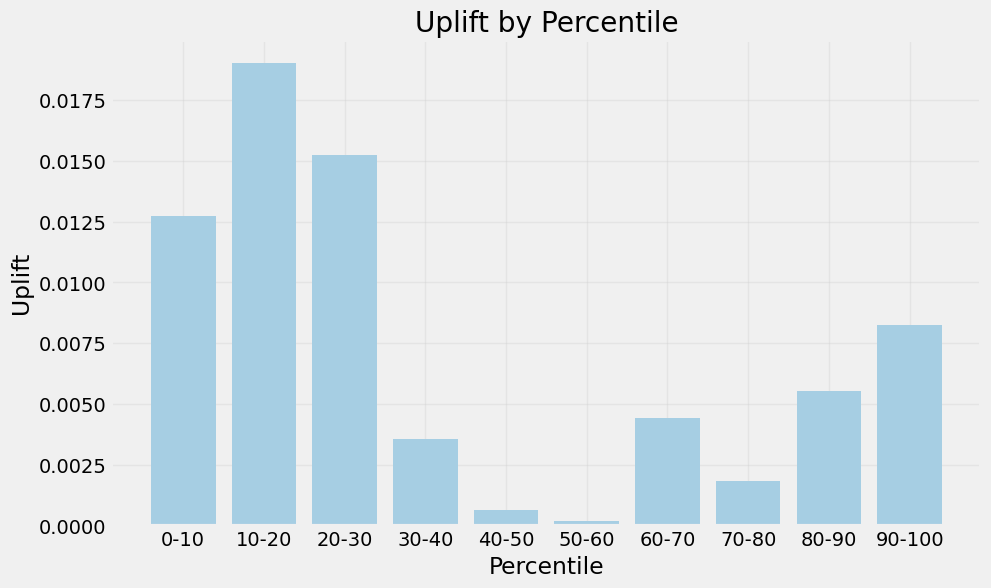

In [21]:
result = uplift_by_percentile(
    y_test, uplift_pred_test_v1, treatment_test, 
    strategy='overall', bins=10
)

plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

### Метод 2 - Пошаговый жадный отбор (Forward Stepwise) по PUC.


 Идея: на каждом шаге добавляем признак, который максимизирует
    совокупный PUC-AUC предиктора (усреднение нормализованных признаков).

In [22]:
def puc_forward_selector(
    X,
    y,
    treatment,
    n_features_to_select=5,
    min_improvement=0.001,
    feature_names=None):
   
    X = np.array(X, dtype=float)
    
    X_norm = X.copy()
    for i in range(X_norm.shape[1]):
        col_range = X_norm[:, i].max() - X_norm[:, i].min()
        if col_range > 0:
            X_norm[:, i] = (X_norm[:, i] - X_norm[:, i].min()) / col_range
    
    y = np.array(y)
    treatment = np.array(treatment)
    n_features = X_norm.shape[1]
    
    remaining = list(range(n_features))
    selected = []
    current_score = 0.0
    selection_history = []
    
    for step in range(n_features_to_select):
        best_score = current_score
        best_feat = None
        
        for feat in remaining:
            score = _compute_marginal_puc(X_norm, y, treatment, selected, feat)
            if score > best_score:
                best_score = score
                best_feat = feat
        
        improvement = best_score - current_score
        if best_feat is None or improvement < min_improvement:
            break
        
        selected.append(best_feat)
        remaining.remove(best_feat)
        current_score = best_score
        
        selection_history.append({
            'step': step + 1,
            'feature': feature_names[best_feat],
            'feature_idx': best_feat,
            'puc_auc': best_score,
            'improvement': improvement
        })
    
    selected_features = np.array(selected)
    summary_df = pd.DataFrame(selection_history)
    
    return selected_features, selection_history, summary_df


In [23]:
selected_idx_fs, feature_scores_fs, summary_df_fs = puc_forward_selector(X_train, y_train, treatment_train, n_features_to_select=10,
                                                                         min_improvement=0.005, feature_names=X_train.columns.tolist())

In [25]:
selected_features_fs = summary_df_fs['feature']

In [26]:
model_t_v2, model_c_v2, uplift_pred_train_v2, auuc_train_v2, puc_train_v2, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features_fs)

[I 2026-04-26 20:26:44,691] A new study created in memory with name: no-name-cedf275e-e67e-4729-9033-aceae581e69c
[I 2026-04-26 20:27:19,534] Trial 2 finished with value: 0.04510852772169731 and parameters: {'depth_c': 8, 'learning_rate_c': 0.010315312759589619, 'iterations_c': 565, 'l2_leaf_reg_c': 4.269139011752536, 'bagging_temperature_c': 3.5510666420539883, 'random_strength_c': 9.842936118255125, 'min_data_in_leaf_c': 31, 'depth_t': 4, 'learning_rate_t': 0.046613834152668863, 'iterations_t': 477, 'l2_leaf_reg_t': 17.96807717779549, 'bagging_temperature_t': 7.253631359119432, 'random_strength_t': 5.46948964312873, 'min_data_in_leaf_t': 35}. Best is trial 2 with value: 0.04510852772169731.


AUUC: 0.442106790609988
PUC: 0.04510852772169731


[I 2026-04-26 20:27:31,485] Trial 11 finished with value: 0.034447298235925364 and parameters: {'depth_c': 4, 'learning_rate_c': 0.013502019869214864, 'iterations_c': 789, 'l2_leaf_reg_c': 3.5247579939383566, 'bagging_temperature_c': 7.262260261447756, 'random_strength_c': 4.312574701322182, 'min_data_in_leaf_c': 77, 'depth_t': 5, 'learning_rate_t': 0.04594834367907329, 'iterations_t': 671, 'l2_leaf_reg_t': 19.46947496609336, 'bagging_temperature_t': 3.64044081626297, 'random_strength_t': 7.188549183708222, 'min_data_in_leaf_t': 20}. Best is trial 2 with value: 0.04510852772169731.


AUUC: 0.4717049561894692
PUC: 0.034447298235925364


[I 2026-04-26 20:27:33,490] Trial 7 finished with value: 0.018121798450407744 and parameters: {'depth_c': 8, 'learning_rate_c': 0.02406588661412975, 'iterations_c': 906, 'l2_leaf_reg_c': 2.870946094775438, 'bagging_temperature_c': 3.694138116389336, 'random_strength_c': 0.14571322011557974, 'min_data_in_leaf_c': 5, 'depth_t': 7, 'learning_rate_t': 0.05916464837852388, 'iterations_t': 524, 'l2_leaf_reg_t': 18.479934943385302, 'bagging_temperature_t': 3.3363672505818642, 'random_strength_t': 0.6137988806545436, 'min_data_in_leaf_t': 29}. Best is trial 2 with value: 0.04510852772169731.


...

AUUC: 0.43896057319877263
PUC: 0.04012157839311915
AUUC: 0.40364168891013835
PUC: 0.02176145228311751


[I 2026-04-26 20:30:26,894] Trial 48 finished with value: 0.04105876345184552 and parameters: {'depth_c': 9, 'learning_rate_c': 0.010029670785916461, 'iterations_c': 511, 'l2_leaf_reg_c': 11.484540763647779, 'bagging_temperature_c': 9.612042443700687, 'random_strength_c': 8.30850751553469, 'min_data_in_leaf_c': 85, 'depth_t': 5, 'learning_rate_t': 0.06467868154746373, 'iterations_t': 737, 'l2_leaf_reg_t': 9.081633650023177, 'bagging_temperature_t': 2.475062505236213, 'random_strength_t': 6.385743223630811, 'min_data_in_leaf_t': 13}. Best is trial 35 with value: 0.05862628318793906.


AUUC: 0.4312194018290251
PUC: 0.04105876345184552


[I 2026-04-26 20:30:27,565] Trial 49 finished with value: 0.043039709154363906 and parameters: {'depth_c': 9, 'learning_rate_c': 0.010198051961549982, 'iterations_c': 518, 'l2_leaf_reg_c': 1.3289353147378142, 'bagging_temperature_c': 2.466519311852043, 'random_strength_c': 8.204646468244707, 'min_data_in_leaf_c': 61, 'depth_t': 5, 'learning_rate_t': 0.05622689248108121, 'iterations_t': 717, 'l2_leaf_reg_t': 9.63499875523251, 'bagging_temperature_t': 2.2416564692305023, 'random_strength_t': 8.174385254109247, 'min_data_in_leaf_t': 32}. Best is trial 35 with value: 0.05862628318793906.


AUUC: 0.420916169542569
PUC: 0.043039709154363906
AUUC: 0.9689412239062011
PUC: 0.07542279497555154


In [27]:
uplift_pred_test_v2, auuc_test_v2, puc_test_v2 = get_uplift(model_t_v2, model_c_v2, X_test, treatment_test, y_test, selected_features_fs)

AUUC: 0.5460994750238044
PUC: 0.06306181543558945


In [72]:
len(selected_features_fs)

3

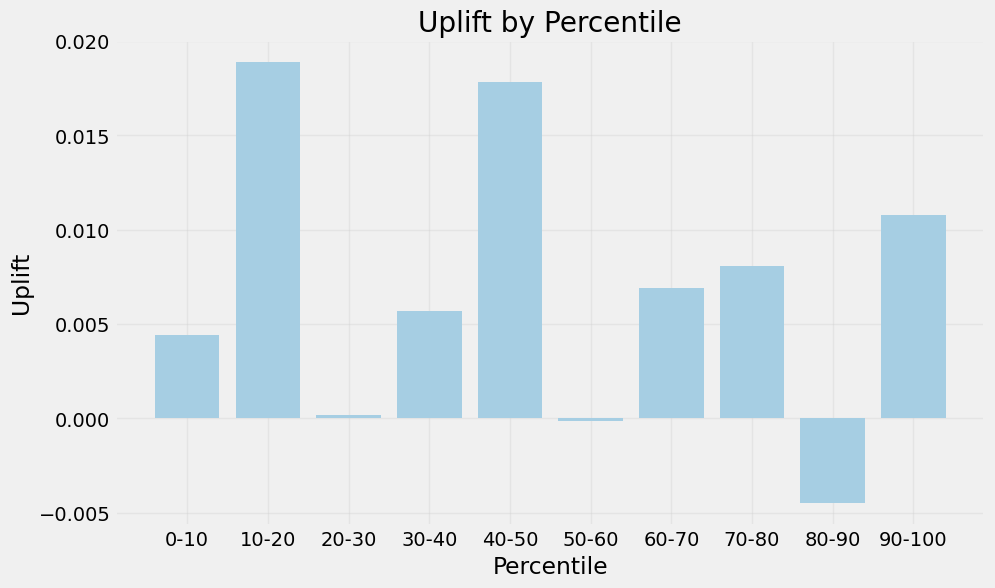

In [28]:
result = uplift_by_percentile(
    y_test, uplift_pred_test_v2, treatment_test, 
    strategy='overall', bins=10
)

plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

### Метод 3 - puc_permutation_importance — Permutation Importance на основе PUC

Метод оценивает важность признака по тому, насколько сильно падает качество uplift-предсказания при случайном перемешивании (permutation) значений этого признака. Чем сильнее падение — тем важнее признак.

In [29]:
def puc_permutation_importance(
    X,
    y,
    treatment,
    uplift_scores,
    n_repeats=20,
    random_state=42,
    feature_names=None
):

    X = np.array(X, dtype=float)
    y = np.array(y)
    treatment = np.array(treatment)
    uplift_scores = np.array(uplift_scores, dtype=float)
    n_features = X.shape[1]
    
    base_score = principled_uplift_auc_score(y, uplift_scores, treatment)
    
    rng = np.random.RandomState(random_state)
    importances = np.zeros((n_features, n_repeats))
    
    for feat_idx in range(n_features):
        for rep in range(n_repeats):
            X_permuted = X.copy()
            X_permuted[:, feat_idx] = rng.permutation(X[:, feat_idx])
            
            perm_score_col = X_permuted[:, feat_idx]
            col_range = perm_score_col.max() - perm_score_col.min()
            if col_range > 0:
                perm_score_col = (perm_score_col - perm_score_col.min()) / col_range
            
            blended = 0.7 * uplift_scores + 0.3 * perm_score_col
            blended_range = blended.max() - blended.min()
            if blended_range > 0:
                blended = (blended - blended.min()) / blended_range
            
            try:
                perm_puc = principled_uplift_auc_score(y, blended, treatment)
            except Exception:
                perm_puc = base_score
            
            importances[feat_idx, rep] = base_score - perm_puc
    
    importances_mean = importances.mean(axis=1)
    importances_std = importances.std(axis=1)
    
    summary_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': importances_mean,
        'importance_std': importances_std,
    }).sort_values('importance_mean', ascending=False).reset_index(drop=True)
    
    return importances, importances_mean, importances_std, base_score, summary_df

In [30]:
model_trt = BASE_MODEL.copy()
model_ctrl = BASE_MODEL.copy()

model_trt.fit(X_train[treatment_train == 1], y_train[treatment_train == 1])
model_ctrl.fit(X_train[treatment_train == 0], y_train[treatment_train == 0])

CatBoostClassifier(loss_function='Logloss', random_state=42, verbose=False)

In [31]:
uplift_scores = model_trt.predict(X_val) - model_ctrl.predict(X_val)

importances, imp_mean, imp_std, base_score, summary_df = puc_permutation_importance(
    X=X_val,
    y=y_val,
    treatment=treatment_val,
    uplift_scores=uplift_scores,
    n_repeats=10,
    random_state=42,
    feature_names=X_train.columns.tolist()
)

In [32]:
selected_features_puc_pi = summary_df[summary_df.importance_mean > 0]['feature']

In [33]:
model_t_v3, model_c_v3, uplift_pred_train_v3, auuc_train_v3, puc_train_v3, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features_puc_pi)

[I 2026-04-26 20:32:53,165] A new study created in memory with name: no-name-1243e5e2-b434-4536-83f0-d921279c4be4
[I 2026-04-26 20:35:41,112] Trial 4 finished with value: 0.02386656848951141 and parameters: {'depth_c': 6, 'learning_rate_c': 0.09781520052995632, 'iterations_c': 581, 'l2_leaf_reg_c': 8.05421616492591, 'bagging_temperature_c': 4.283954113846948, 'random_strength_c': 3.105147115198301, 'min_data_in_leaf_c': 64, 'depth_t': 6, 'learning_rate_t': 0.05193958439112947, 'iterations_t': 439, 'l2_leaf_reg_t': 17.527521278459716, 'bagging_temperature_t': 7.697748045591818, 'random_strength_t': 1.6101290406782942, 'min_data_in_leaf_t': 6}. Best is trial 4 with value: 0.02386656848951141.


AUUC: 0.7615825071400425
PUC: 0.02386656848951141


[I 2026-04-26 20:35:46,755] Trial 3 finished with value: 0.020676315766651535 and parameters: {'depth_c': 5, 'learning_rate_c': 0.07441014778199971, 'iterations_c': 631, 'l2_leaf_reg_c': 12.226797793188993, 'bagging_temperature_c': 5.466954889999459, 'random_strength_c': 2.3543426906058817, 'min_data_in_leaf_c': 33, 'depth_t': 6, 'learning_rate_t': 0.03991084432707879, 'iterations_t': 469, 'l2_leaf_reg_t': 9.619062059524133, 'bagging_temperature_t': 6.489029903137577, 'random_strength_t': 3.4505754132794744, 'min_data_in_leaf_t': 36}. Best is trial 4 with value: 0.02386656848951141.


AUUC: 0.6809391533172888
PUC: 0.020676315766651535


[I 2026-04-26 20:36:41,503] Trial 13 finished with value: 0.011894058648837406 and parameters: {'depth_c': 5, 'learning_rate_c': 0.019734826514505418, 'iterations_c': 687, 'l2_leaf_reg_c': 18.421440080069555, 'bagging_temperature_c': 9.491894680052592, 'random_strength_c': 5.445449187007795, 'min_data_in_leaf_c': 98, 'depth_t': 9, 'learning_rate_t': 0.2424555489548463, 'iterations_t': 385, 'l2_leaf_reg_t': 4.119681913534711, 'bagging_temperature_t': 3.7422351080399197, 'random_strength_t': 7.89335611692273, 'min_data_in_leaf_t': 20}. Best is trial 4 with value: 0.02386656848951141.


...

AUUC: 0.6745087260980582
PUC: 0.06385810450751252


[I 2026-04-26 21:08:00,755] Trial 48 finished with value: 0.06595659834022481 and parameters: {'depth_c': 9, 'learning_rate_c': 0.010032307084646683, 'iterations_c': 619, 'l2_leaf_reg_c': 19.996717795538014, 'bagging_temperature_c': 6.981820522930042, 'random_strength_c': 8.975825219461035, 'min_data_in_leaf_c': 60, 'depth_t': 7, 'learning_rate_t': 0.013959476384241148, 'iterations_t': 1395, 'l2_leaf_reg_t': 5.231235575678519, 'bagging_temperature_t': 2.2749935322412096, 'random_strength_t': 5.7664435543079104, 'min_data_in_leaf_t': 81}. Best is trial 38 with value: 0.0733043378652512.


AUUC: 0.6878980733656771
PUC: 0.06595659834022481


[I 2026-04-26 21:08:42,032] Trial 23 finished with value: 0.05346958367180723 and parameters: {'depth_c': 10, 'learning_rate_c': 0.036763488772738474, 'iterations_c': 1447, 'l2_leaf_reg_c': 1.7372988119320052, 'bagging_temperature_c': 5.721516071350844, 'random_strength_c': 6.815169059528732, 'min_data_in_leaf_c': 5, 'depth_t': 10, 'learning_rate_t': 0.01466815885921733, 'iterations_t': 1377, 'l2_leaf_reg_t': 19.335536851505847, 'bagging_temperature_t': 5.635964381547492, 'random_strength_t': 1.6180037727866274, 'min_data_in_leaf_t': 90}. Best is trial 38 with value: 0.0733043378652512.


AUUC: 0.5081908129772316
PUC: 0.05346958367180723
AUUC: 2.743828420866472
PUC: 0.12965357451034823


In [34]:
uplift_pred_test_v3, auuc_test_v3, puc_test_v3 = get_uplift(model_t_v3, model_c_v3, X_test, treatment_test, y_test, selected_features_puc_pi)

AUUC: 0.58571916426976
PUC: 0.07085283037481024


In [73]:
len(selected_features_puc_pi)

192

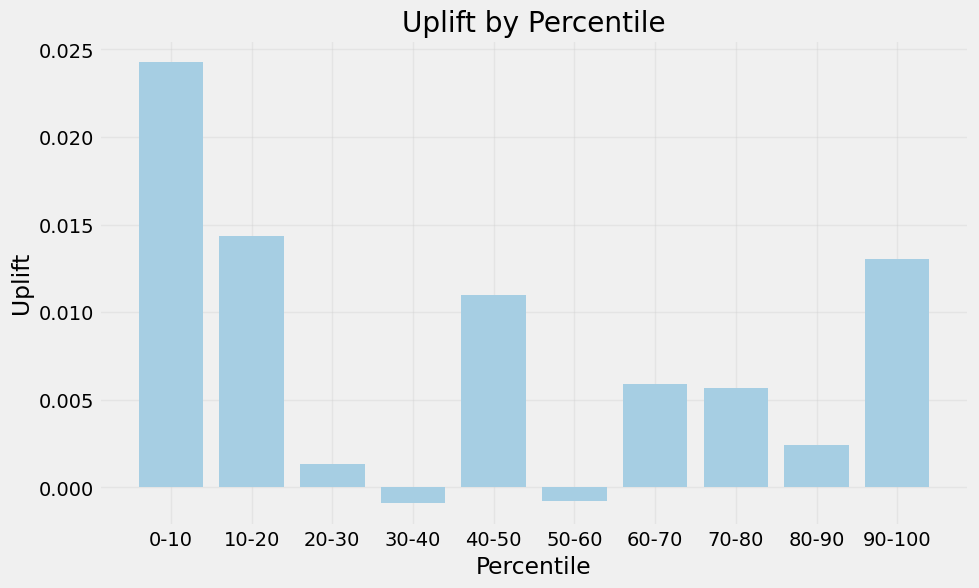

In [35]:
result = uplift_by_percentile(
    y_test, uplift_pred_test_v3, treatment_test, 
    strategy='overall', bins=10
)

plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

### Метод 4 -  Гибридный каузально-PUC отбор признаков.

Идея объединения каузального анализа и PUC:

Uplift-моделирование — это задача оценки индивидуального каузального эффекта (ITE/CATE). В каузальном графе (DAG) признаки делятся на:
    
    1. Confounder (Z): влияет и на T, и на Y → обязательно включать
    2. Effect Modifier (X): меняет CATE, но не T → именно они нужны
    3. Instrument (W): влияет только на T → включать опасно (смещение)
    4. Collider (C): общий потомок T и Y → включать запрещено (смещение)

In [38]:
def causal_puc_selector(
    X,
    y,
    treatment,
    alpha=0.6,
    beta=0.3,
    gamma=0.5,
    top_k=None,
    threshold=0.0,
    feature_names=None
):

    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)
    treatment = np.array(treatment, dtype=float)
    n_features = X.shape[1]
    
    records = []
    for i in range(n_features):
        xi = X[:, i]
        corr_y, _ = stats.spearmanr(xi, y)
        corr_t, _ = stats.spearmanr(xi, treatment)
        puc_score = _compute_puc_for_feature(xi, y, treatment)
        
        causal_score = (
            alpha * max(puc_score, 0)
            + beta * (abs(corr_y) - gamma * abs(corr_t))
        )
        
        role = _causal_role(corr_y, corr_t, puc_score)
        
        records.append({
            'feature': feature_names[i],
            'feature_idx': i,
            'puc_auc': puc_score,
            'corr_outcome': corr_y,
            'corr_treatment': corr_t,
            'causal_score': causal_score,
            'causal_role': role,
        })
    
    summary_df = pd.DataFrame(records).sort_values(
        'causal_score', ascending=False
    ).reset_index(drop=True)
    
    if top_k is not None:
        selected = summary_df.head(top_k)
    else:
        selected = summary_df[summary_df['causal_score'] >= threshold]
    
    selected_features = selected['feature'].values
    
    return selected_features, summary_df


def _causal_role(corr_y: float, corr_t: float, puc: float) -> str:

    if abs(corr_t) > 0.3 and abs(corr_y) > 0.3:
        return 'confounder'
    elif abs(corr_t) > 0.3 and abs(corr_y) < 0.15:
        return 'instrument'
    elif abs(corr_t) < 0.15 and abs(corr_y) > 0.3:
        return 'prognostic'
    elif puc > 0.05:
        return 'effect_modifier'
    else:
        return 'noise'


In [39]:
selected_features_causal, summary_df_causal = causal_puc_selector(
    X=X_train,
    y=y_train,
    treatment=treatment_train,
    alpha=0.6,
    beta=0.3,
    gamma=0.5,
    top_k=50,
    feature_names=X_train.columns.tolist()
)


In [40]:
model_t_v4, model_c_v4, uplift_pred_train_v4, auuc_train_v4, puc_train_v4, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features_causal)

[I 2026-04-26 21:11:11,661] A new study created in memory with name: no-name-4d636307-5c62-41b8-ac86-da8f47eac5c5
[I 2026-04-26 21:13:03,267] Trial 6 finished with value: 0.01772178339308479 and parameters: {'depth_c': 4, 'learning_rate_c': 0.039138651908883146, 'iterations_c': 667, 'l2_leaf_reg_c': 7.025771165547693, 'bagging_temperature_c': 3.658383725058517, 'random_strength_c': 0.81253689407073, 'min_data_in_leaf_c': 52, 'depth_t': 7, 'learning_rate_t': 0.029863731158295482, 'iterations_t': 641, 'l2_leaf_reg_t': 18.70845335551483, 'bagging_temperature_t': 3.5626410531229737, 'random_strength_t': 8.808365518187474, 'min_data_in_leaf_t': 34}. Best is trial 6 with value: 0.01772178339308479.


AUUC: 0.5546089594199956
PUC: 0.01772178339308479


[I 2026-04-26 21:13:29,105] Trial 10 finished with value: 0.05469163202940413 and parameters: {'depth_c': 4, 'learning_rate_c': 0.02188551105472429, 'iterations_c': 313, 'l2_leaf_reg_c': 6.084692130944346, 'bagging_temperature_c': 0.4635533439064832, 'random_strength_c': 3.473328663056466, 'min_data_in_leaf_c': 26, 'depth_t': 4, 'learning_rate_t': 0.0128510573733643, 'iterations_t': 1232, 'l2_leaf_reg_t': 19.227559016257004, 'bagging_temperature_t': 6.838513902365295, 'random_strength_t': 4.912355245814396, 'min_data_in_leaf_t': 78}. Best is trial 10 with value: 0.05469163202940413.


AUUC: 0.5148695478295173
PUC: 0.05469163202940413


[I 2026-04-26 21:13:44,462] Trial 3 finished with value: 0.0071307391001926455 and parameters: {'depth_c': 5, 'learning_rate_c': 0.20826362583596708, 'iterations_c': 626, 'l2_leaf_reg_c': 18.747318999737907, 'bagging_temperature_c': 6.860082507687244, 'random_strength_c': 5.1400264602477455, 'min_data_in_leaf_c': 67, 'depth_t': 6, 'learning_rate_t': 0.1602514180216857, 'iterations_t': 1045, 'l2_leaf_reg_t': 10.811915196909151, 'bagging_temperature_t': 2.565229333055389, 'random_strength_t': 1.5119281910778226, 'min_data_in_leaf_t': 23}. Best is trial 10 with value: 0.05469163202940413.


...

AUUC: 0.510831125895723
PUC: 0.04280735359922865


[I 2026-04-26 21:25:59,004] Trial 48 finished with value: 0.027267852026109967 and parameters: {'depth_c': 9, 'learning_rate_c': 0.010267347809878749, 'iterations_c': 1372, 'l2_leaf_reg_c': 3.37301878843925, 'bagging_temperature_c': 1.1619270896713516, 'random_strength_c': 5.407940610811718, 'min_data_in_leaf_c': 30, 'depth_t': 5, 'learning_rate_t': 0.01911799704837102, 'iterations_t': 1097, 'l2_leaf_reg_t': 17.365104775605285, 'bagging_temperature_t': 9.15619328114581, 'random_strength_t': 5.109486780105053, 'min_data_in_leaf_t': 89}. Best is trial 10 with value: 0.05469163202940413.


AUUC: 0.517157281149801
PUC: 0.027267852026109967


[I 2026-04-26 21:26:05,233] Trial 49 finished with value: 0.019306661282171542 and parameters: {'depth_c': 9, 'learning_rate_c': 0.013344297633743785, 'iterations_c': 1366, 'l2_leaf_reg_c': 12.725197734731653, 'bagging_temperature_c': 0.9467529099593542, 'random_strength_c': 5.110384876793998, 'min_data_in_leaf_c': 38, 'depth_t': 5, 'learning_rate_t': 0.01851553115066817, 'iterations_t': 1372, 'l2_leaf_reg_t': 17.241980286851664, 'bagging_temperature_t': 6.357632442426761, 'random_strength_t': 4.952442706139984, 'min_data_in_leaf_t': 89}. Best is trial 10 with value: 0.05469163202940413.


AUUC: 0.47268792905186796
PUC: 0.019306661282171542
AUUC: 1.084292564550462
PUC: 0.07730493336107715


In [41]:
uplift_pred_test_v4, auuc_test_v4, puc_test_v4 = get_uplift(model_t_v4, model_c_v4, X_test, treatment_test, y_test, selected_features_causal)

AUUC: 0.5696532081891804
PUC: 0.06289413573715671


In [74]:
len(selected_features_causal)

50

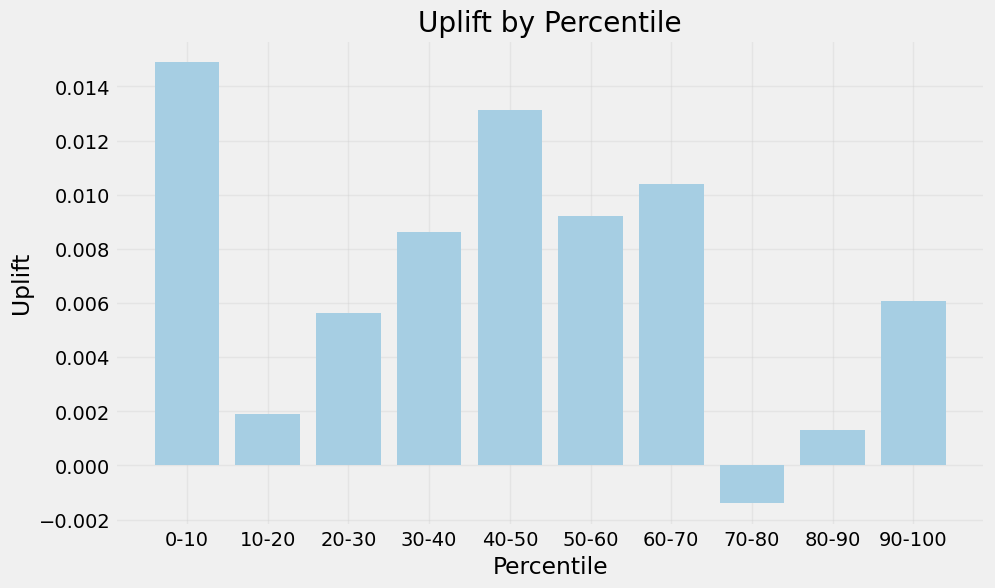

In [42]:
result = uplift_by_percentile(
    y_test, uplift_pred_test_v4, treatment_test, 
    strategy='overall', bins=10
)

plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

### Метод 5 - PUCUpliftTree

Дерево принятия решений для uplift-моделирования, использующее PUC-gain как критерий качества разбиения (вместо стандартного KL-дивергенции или ED²/Chi² из пакета CausalML).
    
Критерий разбиения:
```
    PUC_gain(split) = PUC_AUC(left_child) · w_left
                    + PUC_AUC(right_child) · w_right
                    - PUC_AUC(parent)
```
где w_left/w_right — доли наблюдений в дочерних узлах.

Важность признаков вычисляется как суммарный взвешенный PUC-gain по всем разбиениям дерева, использующим данный признак.


In [43]:
class PUCUpliftTreeNode:

    def __init__(self, depth=0):
        self.depth = depth
        self.feature_idx = None
        self.threshold = None
        self.left = None
        self.right = None
        self.is_leaf = False
        self.uplift_score = None
        self.n_samples = None
        self.n_treatment = None
        self.n_control = None
        self.puc_gain = 0.0
        self.y_mean_t = None
        self.y_mean_c = None


class PUCUpliftTree:

    def __init__(self, max_depth=4, min_samples_leaf=50, n_thresholds=10):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.n_thresholds = n_thresholds
        self.root_ = None
        self.feature_importances_ = None
        self.n_features_ = None
        self.feature_names_ = None
        self._split_records = []

    def _node_puc(self, y, treatment):
        n_t = treatment.sum()
        n_c = len(treatment) - n_t
        if n_t < 5 or n_c < 5:
            return 0.0
        if len(np.unique(y)) < 2:
            return 0.0

        try:
            proxy_uplift = y * treatment - y * (1 - treatment)
            return principled_uplift_auc_score(y, proxy_uplift.astype(float), treatment)
        except Exception:
            return 0.0

    def _best_split(self, X, y, treatment):
        n = len(y)
        best_gain = -np.inf
        best_feat = None
        best_thresh = None

        parent_puc = self._node_puc(y, treatment)

        for feat_idx in range(X.shape[1]):
            values = X[:, feat_idx]
            thresholds = np.percentile(
                values,
                np.linspace(10, 90, self.n_thresholds)
            )
            thresholds = np.unique(thresholds)

            for thresh in thresholds:
                left_mask = values <= thresh
                right_mask = ~left_mask

                n_left = left_mask.sum()
                n_right = right_mask.sum()

                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                puc_left = self._node_puc(y[left_mask], treatment[left_mask])
                puc_right = self._node_puc(y[right_mask], treatment[right_mask])

                gain = (
                    puc_left * (n_left / n)
                    + puc_right * (n_right / n)
                    - parent_puc
                )

                if gain > best_gain:
                    best_gain = gain
                    best_feat = feat_idx
                    best_thresh = thresh

        return best_feat, best_thresh, best_gain

    def _build(self, X, y, treatment, depth):
        node = PUCUpliftTreeNode(depth=depth)
        node.n_samples = len(y)
        node.n_treatment = treatment.sum()
        node.n_control = node.n_samples - node.n_treatment

        y_t = y[treatment == 1]
        y_c = y[treatment == 0]
        node.y_mean_t = y_t.mean() if len(y_t) > 0 else 0.0
        node.y_mean_c = y_c.mean() if len(y_c) > 0 else 0.0
        node.uplift_score = node.y_mean_t - node.y_mean_c

        if (depth >= self.max_depth
                or node.n_treatment < self.min_samples_leaf
                or node.n_control < self.min_samples_leaf):
            node.is_leaf = True
            return node

        feat, thresh, gain = self._best_split(X, y, treatment)

        if feat is None or gain <= 0:
            node.is_leaf = True
            return node

        node.feature_idx = feat
        node.threshold = thresh
        node.puc_gain = gain

        self._split_records.append({
            'feature_idx': feat,
            'gain': gain,
            'n_samples': node.n_samples
        })

        mask_left = X[:, feat] <= thresh
        mask_right = ~mask_left

        node.left = self._build(X[mask_left], y[mask_left], treatment[mask_left], depth + 1)
        node.right = self._build(X[mask_right], y[mask_right], treatment[mask_right], depth + 1)

        return node

    def fit(self, X, y, treatment, feature_names=None):
        X = np.array(X, dtype=float)
        y = np.array(y)
        treatment = np.array(treatment)
        self.n_features_ = X.shape[1]

        self.feature_names_ = feature_names

        self._split_records = []
        self.root_ = self._build(X, y, treatment, depth=0)

        importances = np.zeros(self.n_features_)
        for record in self._split_records:
            importances[record['feature_idx']] += (
                record['gain'] * record['n_samples']
            )

        total = importances.sum()
        if total > 0:
            importances /= total
        self.feature_importances_ = importances
        return self

    def _predict_node(self, x, node):
        if node.is_leaf:
            return node.uplift_score
        if x[node.feature_idx] <= node.threshold:
            return self._predict_node(x, node.left)
        else:
            return self._predict_node(x, node.right)

    def predict(self, X):
        X = np.array(X, dtype=float)
        return np.array([self._predict_node(x, self.root_) for x in X])

    def get_feature_importance_df(self):
        return pd.DataFrame({
            'feature': self.feature_names_,
            'importance': self.feature_importances_,
        }).sort_values('importance', ascending=False)

    def _print_tree(self, node, prefix='', is_left=True):
        if node is None:
            return
        connector = '├── ' if is_left else '└── '
        if node.is_leaf:
            print(f'{prefix}{connector}[LEAF] uplift={node.uplift_score:.4f}'
                  f'n={node.n_samples} (T={node.n_treatment}, C={node.n_control})')
        else:
            feat_name = self.feature_names_[node.feature_idx]
            print(f'{prefix}{connector}[{feat_name} <= {node.threshold:.4f}] '
                  f'puc_gain={node.puc_gain:.4f} n={node.n_samples}')
            ext = '│   ' if is_left else '    '
            self._print_tree(node.left, prefix + ext, True)
            self._print_tree(node.right, prefix + ext, False)

    def print_tree(self):
        print('PUC Uplift Tree')
        self._print_tree(self.root_, '', True)


In [44]:
puc_tree = PUCUpliftTree(max_depth=4, min_samples_leaf=40, n_thresholds=8)
puc_tree.fit(X_train, y_train, treatment_train, feature_names=X_train.columns.tolist())
puc_tree.print_tree()

PUC Uplift Tree
├── [response_sms <= 0.0000] puc_gain=0.0040 n=412191
│   ├── [response_viber <= 0.2000] puc_gain=0.0216 n=71741
│   │   ├── [children <= -100.0000] puc_gain=0.0286 n=23771
│   │   │   ├── [cheque_count_12m_g48 <= 0.0000] puc_gain=0.0005 n=5152
│   │   │   │   ├── [LEAF] uplift=0.0388 n=1076 (T=803, C=273)
│   │   │   │   └── [LEAF] uplift=-0.0082 n=4076 (T=3106, C=970)
│   │   │   └── [k_var_disc_share_6m_g49 <= 0.0000] puc_gain=0.0295 n=18619
│   │   │       ├── [LEAF] uplift=0.0060 n=10877 (T=5997, C=4880)
│   │   │       └── [LEAF] uplift=0.0188 n=7742 (T=2084, C=5658)
│   │   └── [response_viber <= 0.9286] puc_gain=0.0023 n=47970
│   │       ├── [response_viber <= 0.5000] puc_gain=0.0315 n=4904
│   │       │   ├── [LEAF] uplift=0.0077 n=1626 (T=762, C=864)
│   │       │   └── [LEAF] uplift=0.0078 n=3278 (T=2493, C=785)
│   │       └── [k_var_disc_per_cheque_15d <= -100.0000] puc_gain=0.0001 n=43066
│   │           ├── [LEAF] uplift=0.0121 n=7954 (T=6043, C=1911)
│ 

In [45]:
summary_df = puc_tree.get_feature_importance_df()

In [46]:
selected_features_tree = summary_df[summary_df['importance'] > 0]

In [47]:
model_t_v5, model_c_v5, uplift_pred_train_v5, auuc_train_v5, puc_train_v5, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features_tree)

[I 2026-04-26 21:30:41,079] A new study created in memory with name: no-name-66f2a3bc-1535-4833-bde3-998c4c8d8315
[I 2026-04-26 21:31:30,751] Trial 7 finished with value: 0.004614431832879007 and parameters: {'depth_c': 10, 'learning_rate_c': 0.18890376569038556, 'iterations_c': 411, 'l2_leaf_reg_c': 5.504105720809526, 'bagging_temperature_c': 3.5639071372924667, 'random_strength_c': 4.252141880870031, 'min_data_in_leaf_c': 69, 'depth_t': 8, 'learning_rate_t': 0.09848241549940377, 'iterations_t': 363, 'l2_leaf_reg_t': 12.216860920153595, 'bagging_temperature_t': 3.8574093971777157, 'random_strength_t': 9.196656250099553, 'min_data_in_leaf_t': 69}. Best is trial 7 with value: 0.004614431832879007.


AUUC: 0.5376657871052333
PUC: 0.004614431832879007


[I 2026-04-26 21:31:38,159] Trial 11 finished with value: 0.004614431832879007 and parameters: {'depth_c': 6, 'learning_rate_c': 0.05324114788220157, 'iterations_c': 494, 'l2_leaf_reg_c': 3.5572772570369433, 'bagging_temperature_c': 8.46340030213256, 'random_strength_c': 2.989929508560998, 'min_data_in_leaf_c': 4, 'depth_t': 7, 'learning_rate_t': 0.2852448869162863, 'iterations_t': 407, 'l2_leaf_reg_t': 9.930147247027465, 'bagging_temperature_t': 5.645319114732169, 'random_strength_t': 0.5972894677278262, 'min_data_in_leaf_t': 50}. Best is trial 7 with value: 0.004614431832879007.


AUUC: 0.5376657871052333
PUC: 0.004614431832879007


[I 2026-04-26 21:31:38,682] Trial 13 finished with value: 0.004614431832879007 and parameters: {'depth_c': 8, 'learning_rate_c': 0.11277823774264503, 'iterations_c': 731, 'l2_leaf_reg_c': 14.038691517954938, 'bagging_temperature_c': 7.618529597295776, 'random_strength_c': 5.405628781911203, 'min_data_in_leaf_c': 3, 'depth_t': 4, 'learning_rate_t': 0.05801493378109038, 'iterations_t': 366, 'l2_leaf_reg_t': 2.352587354330022, 'bagging_temperature_t': 5.738229827472761, 'random_strength_t': 5.815421958392535, 'min_data_in_leaf_t': 75}. Best is trial 7 with value: 0.004614431832879007.


...

AUUC: 0.5376657871052333
PUC: 0.004614431832879007


[I 2026-04-26 21:34:51,272] Trial 48 finished with value: 0.004614431832879007 and parameters: {'depth_c': 8, 'learning_rate_c': 0.016879430022249814, 'iterations_c': 966, 'l2_leaf_reg_c': 7.9865205847635075, 'bagging_temperature_c': 0.8981472345802444, 'random_strength_c': 4.485820996364346, 'min_data_in_leaf_c': 56, 'depth_t': 8, 'learning_rate_t': 0.051941585834580986, 'iterations_t': 1352, 'l2_leaf_reg_t': 17.419450557306895, 'bagging_temperature_t': 8.169948032129811, 'random_strength_t': 6.790169298717864, 'min_data_in_leaf_t': 62}. Best is trial 7 with value: 0.004614431832879007.


AUUC: 0.5376657871052333
PUC: 0.004614431832879007


[I 2026-04-26 21:34:54,026] Trial 49 finished with value: 0.004614431832879007 and parameters: {'depth_c': 7, 'learning_rate_c': 0.021043259309268262, 'iterations_c': 1067, 'l2_leaf_reg_c': 8.129867736723988, 'bagging_temperature_c': 1.03434181224371, 'random_strength_c': 0.49138782932458236, 'min_data_in_leaf_c': 56, 'depth_t': 8, 'learning_rate_t': 0.05055090763998874, 'iterations_t': 1141, 'l2_leaf_reg_t': 16.956882846331254, 'bagging_temperature_t': 4.7730197655483915, 'random_strength_t': 7.456711176093576, 'min_data_in_leaf_t': 57}. Best is trial 7 with value: 0.004614431832879007.


AUUC: 0.5376657871052333
PUC: 0.004614431832879007
AUUC: 0.5766993063708056
PUC: 0.0049645186416363875


In [75]:
len(selected_features_tree)

7

In [48]:
uplift_pred_test_v5, auuc_test_v5, puc_test_v5 = get_uplift(model_t_v5, model_c_v5, X_test, treatment_test, y_test, selected_features_tree)

AUUC: 0.3762017851309128
PUC: 0.001917091159780756


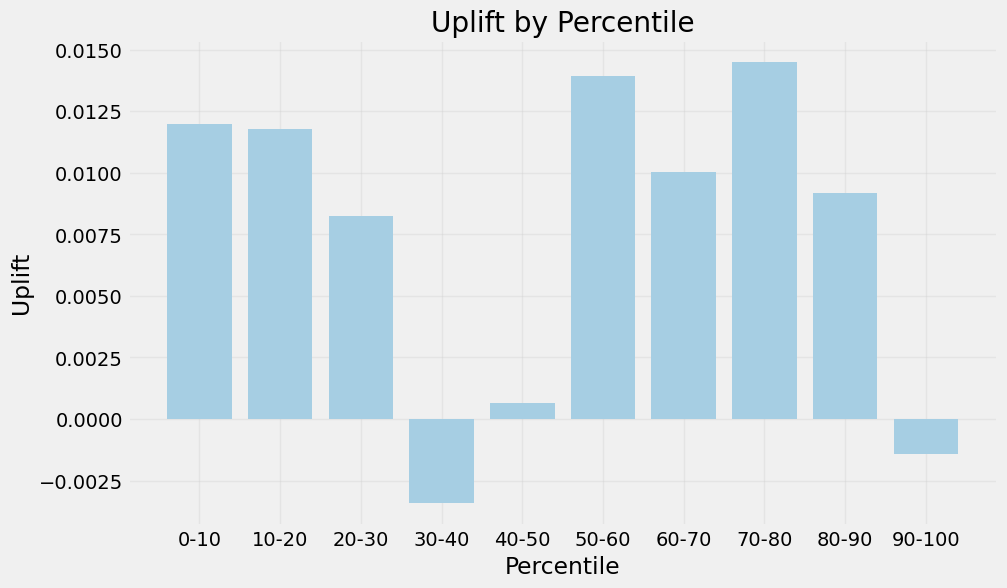

In [49]:
result = uplift_by_percentile(
    y_test, uplift_pred_test_v5, treatment_test, 
    strategy='overall', bins=10
)

plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

In [55]:
selected_features_tree_v2 = summary_df['feature'][:50].values

In [56]:
model_t_v6, model_c_v6, uplift_pred_train_v6, auuc_train_v6, puc_train_v6, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features_tree_v2)

[I 2026-04-26 21:43:42,042] A new study created in memory with name: no-name-433c2332-65b0-4241-acd2-7c8306e1164a
[I 2026-04-26 21:45:18,940] Trial 9 finished with value: 0.02662176691658915 and parameters: {'depth_c': 8, 'learning_rate_c': 0.16435466254135944, 'iterations_c': 603, 'l2_leaf_reg_c': 10.753862807071997, 'bagging_temperature_c': 4.391908374426709, 'random_strength_c': 4.380520924504259, 'min_data_in_leaf_c': 59, 'depth_t': 4, 'learning_rate_t': 0.03265699801874461, 'iterations_t': 623, 'l2_leaf_reg_t': 2.0838664277348684, 'bagging_temperature_t': 7.327130244824732, 'random_strength_t': 0.3487808489155575, 'min_data_in_leaf_t': 93}. Best is trial 9 with value: 0.02662176691658915.


AUUC: 0.5326212509427471
PUC: 0.02662176691658915


[I 2026-04-26 21:45:19,905] Trial 0 finished with value: 0.03417007684710632 and parameters: {'depth_c': 8, 'learning_rate_c': 0.02132622612358837, 'iterations_c': 619, 'l2_leaf_reg_c': 16.08917945940802, 'bagging_temperature_c': 4.953798213665279, 'random_strength_c': 1.1813468063625987, 'min_data_in_leaf_c': 6, 'depth_t': 7, 'learning_rate_t': 0.08919189220035967, 'iterations_t': 465, 'l2_leaf_reg_t': 19.518952780752084, 'bagging_temperature_t': 9.678010798984914, 'random_strength_t': 2.761232257597266, 'min_data_in_leaf_t': 72}. Best is trial 0 with value: 0.03417007684710632.


AUUC: 0.5242018672146088
PUC: 0.03417007684710632


[I 2026-04-26 21:45:21,597] Trial 13 finished with value: 0.04105944613479508 and parameters: {'depth_c': 9, 'learning_rate_c': 0.01122748837997224, 'iterations_c': 680, 'l2_leaf_reg_c': 6.949065703550986, 'bagging_temperature_c': 4.12472180870695, 'random_strength_c': 8.398436648122564, 'min_data_in_leaf_c': 64, 'depth_t': 4, 'learning_rate_t': 0.06494627643243024, 'iterations_t': 410, 'l2_leaf_reg_t': 12.666851446288804, 'bagging_temperature_t': 3.6953390599793225, 'random_strength_t': 2.794634445132944, 'min_data_in_leaf_t': 82}. Best is trial 13 with value: 0.04105944613479508.


...

AUUC: 0.6067647530877763
PUC: 0.035981793225723924


[I 2026-04-26 21:58:39,647] Trial 48 finished with value: 0.05300297062379414 and parameters: {'depth_c': 9, 'learning_rate_c': 0.014750544797466195, 'iterations_c': 452, 'l2_leaf_reg_c': 3.8278324715913077, 'bagging_temperature_c': 7.47451046475313, 'random_strength_c': 3.2667453127203383, 'min_data_in_leaf_c': 22, 'depth_t': 8, 'learning_rate_t': 0.04168638559230175, 'iterations_t': 525, 'l2_leaf_reg_t': 7.2792710012971025, 'bagging_temperature_t': 4.730861430100806, 'random_strength_t': 7.434435166104496, 'min_data_in_leaf_t': 73}. Best is trial 37 with value: 0.05539123494424849.


AUUC: 0.7360652387782386
PUC: 0.05300297062379414


[I 2026-04-26 21:58:41,609] Trial 49 finished with value: 0.044444856669475535 and parameters: {'depth_c': 9, 'learning_rate_c': 0.01458138841525951, 'iterations_c': 444, 'l2_leaf_reg_c': 3.3081197434494154, 'bagging_temperature_c': 7.85445049257852, 'random_strength_c': 3.090428293442431, 'min_data_in_leaf_c': 24, 'depth_t': 8, 'learning_rate_t': 0.023273935376585224, 'iterations_t': 504, 'l2_leaf_reg_t': 15.584546717744463, 'bagging_temperature_t': 4.791366935948654, 'random_strength_t': 7.379651542500916, 'min_data_in_leaf_t': 78}. Best is trial 37 with value: 0.05539123494424849.


AUUC: 0.6530654168518515
PUC: 0.044444856669475535
AUUC: 6.31023689048318
PUC: 0.24306857379161015


In [57]:
uplift_pred_test_v6, auuc_test_v6, puc_test_v6 = get_uplift(model_t_v6, model_c_v6, X_test, treatment_test, y_test, selected_features_tree_v2)

AUUC: 0.5905381923830065
PUC: 0.055453649070843096


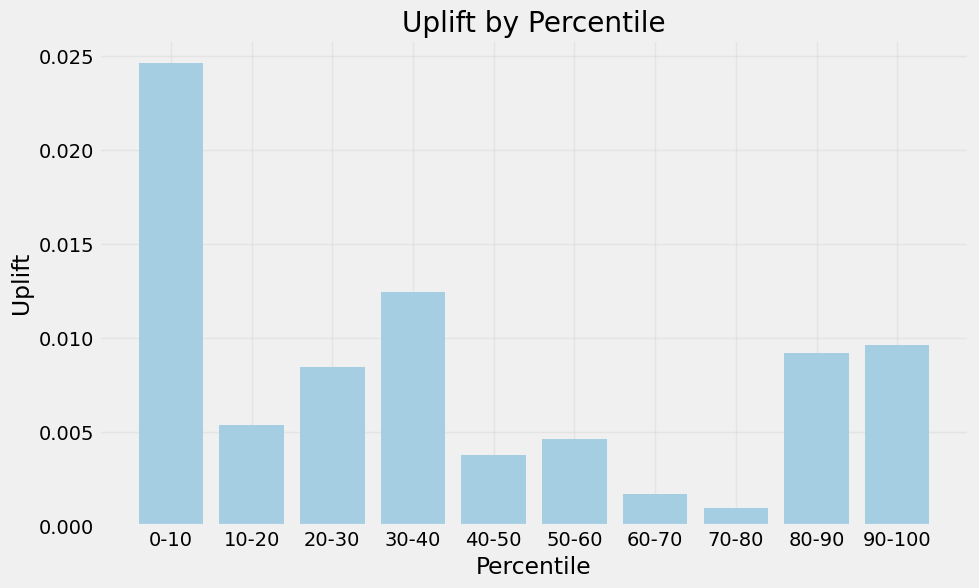

In [58]:
result = uplift_by_percentile(
    y_test, uplift_pred_test_v6, treatment_test, 
    strategy='overall', bins=10
)

plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()